In [234]:
import pandas as pd
import numpy as np

data = pd.read_csv('../clean_housing.csv')
filter_data = data[['price', 'url',
    'sqfeet', 'beds', 'baths', 'cats_allowed', 'dogs_allowed','smoking_allowed','region', 
    'state']]
filter_data = filter_data[
    (filter_data['state'].str.upper() == 'IL') & (filter_data['region']!='chicago')]
filter_data = filter_data.rename(columns={'price': 'price_rent'})
filter_data

,price_rent,url,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,region,state
44442,850,https://bn.craigslist.org/apa/d/bloomington-ca...,1100,2,1.0,1,1,1,bloomington-normal,il
44457,625,https://bn.craigslist.org/apa/d/bloomington-2-...,900,2,1.0,1,1,1,bloomington-normal,il
45471,635,https://decatur.craigslist.org/apa/d/decatur-u...,700,1,1.0,1,1,1,decatur,il
45499,600,https://decatur.craigslist.org/apa/d/decatur-n...,700,1,1.0,1,1,1,decatur,il
45515,534,https://decatur.craigslist.org/apa/d/decatur-h...,460,0,1.0,1,1,1,decatur,il
...,...,...,...,...,...,...,...,...,...,...
56386,810,https://quincy.craigslist.org/apa/d/quincy-3-b...,1140,3,2.0,1,1,1,western IL,il
56387,642,https://quincy.craigslist.org/apa/d/burlington...,955,2,1.0,0,0,1,western IL,il
56388,1500,https://quincy.craigslist.org/apa/d/short-term...,1800,3,1.0,0,0,0,western IL,il
56390,642,https://quincy.craigslist.org/apa/d/burlington...,955,2,1.0,0,0,1,western IL,il


In [235]:
filter_data=filter_data[(filter_data['price_rent']>=100)]
filter_data

,price_rent,url,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,region,state
44442,850,https://bn.craigslist.org/apa/d/bloomington-ca...,1100,2,1.0,1,1,1,bloomington-normal,il
44457,625,https://bn.craigslist.org/apa/d/bloomington-2-...,900,2,1.0,1,1,1,bloomington-normal,il
45471,635,https://decatur.craigslist.org/apa/d/decatur-u...,700,1,1.0,1,1,1,decatur,il
45499,600,https://decatur.craigslist.org/apa/d/decatur-n...,700,1,1.0,1,1,1,decatur,il
45515,534,https://decatur.craigslist.org/apa/d/decatur-h...,460,0,1.0,1,1,1,decatur,il
...,...,...,...,...,...,...,...,...,...,...
56386,810,https://quincy.craigslist.org/apa/d/quincy-3-b...,1140,3,2.0,1,1,1,western IL,il
56387,642,https://quincy.craigslist.org/apa/d/burlington...,955,2,1.0,0,0,1,western IL,il
56388,1500,https://quincy.craigslist.org/apa/d/short-term...,1800,3,1.0,0,0,0,western IL,il
56390,642,https://quincy.craigslist.org/apa/d/burlington...,955,2,1.0,0,0,1,western IL,il


First 5 rows of the dataset:
       price_rent  sqfeet  beds  baths  cats_allowed  dogs_allowed  \
44442         850    1100     2    1.0             1             1   
44457         625     900     2    1.0             1             1   
45471         635     700     1    1.0             1             1   
45499         600     700     1    1.0             1             1   
45515         534     460     0    1.0             1             1   

       smoking_allowed              region state  
44442                1  bloomington-normal    il  
44457                1  bloomington-normal    il  
45471                1             decatur    il  
45499                1             decatur    il  
45515                1             decatur    il  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 5376 entries, 44442 to 56391
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price_rent       53

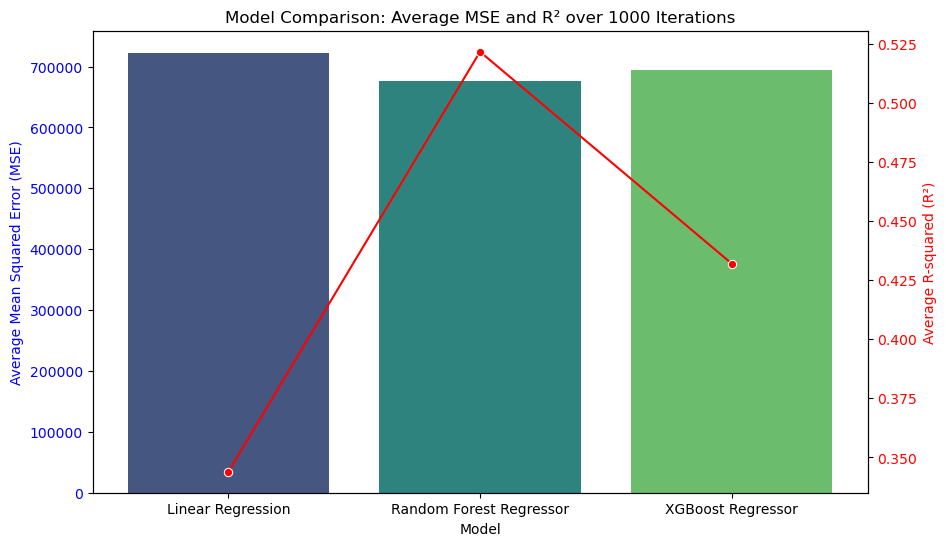

In [227]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ----------------------------------------
# 1. Load and Inspect the Dataset
# ----------------------------------------

df = filter_data  

print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values in Each Column:")
print(df.isnull().sum())

# ----------------------------------------
# 2. Data Preprocessing
# ----------------------------------------

# Handle missing values by dropping rows with missing values
df = df.dropna()
print("\nAfter dropping missing values, dataset shape:", df.shape)

# Log transformation for target variable if skewed
skewness = df['price_rent'].skew()
print(f"\nSkewness of 'price_rent': {skewness:.2f}")

if skewness > 1 or skewness < -1:
    df['price_rent_log'] = np.log1p(df['price_rent'])  # log1p handles zero values
    target = 'price_rent_log'
    print("Applied log transformation to 'price_rent'.")
else:
    target = 'price_rent'
    print("No transformation applied to 'price_rent'.")

# Define features and target
X = df.drop(['price_rent', 'price_rent_log'], axis=1, errors='ignore')
y = df[target]

# Identify categorical and numerical features
categorical_features = ['cats_allowed', 'dogs_allowed', 'smoking_allowed', 'region', 'state']
numerical_features = ['sqfeet', 'beds', 'baths']

print("\nCategorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

# Convert categorical columns to 'category' dtype if not already
for col in categorical_features:
    if df[col].dtype != 'category':
        df[col] = df[col].astype('category')

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# ----------------------------------------
# 3. Model Evaluation Across Multiple Splits
# ----------------------------------------

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=None),
    'XGBoost Regressor': XGBRegressor(n_estimators=100, random_state=None, objective='reg:squarederror')
}

# Initialize results storage
results = {
    'Linear Regression': {'MSE': [], 'R2': []},
    'Random Forest Regressor': {'MSE': [], 'R2': []},
    'XGBoost Regressor': {'MSE': [], 'R2': []}
}

n_loop = 1000  # Number of iterations

for i in range(n_loop):
    print(f"\n--- Iteration {i+1} ---")
    
    # Split the data into training and testing sets without setting random_state
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=None)
    
    # Train and evaluate each model
    for name, model in models.items():
        # Create pipeline
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('regressor', model)
        ])
        
        # Train the model
        pipeline.fit(X_train, y_train)
        
        # Predict on test set
        y_pred = pipeline.predict(X_test)
        
        # If log-transformed, convert back to original scale
        if target == 'price_rent_log':
            y_test_original = np.expm1(y_test)
            y_pred_original = np.expm1(y_pred)
        else:
            y_test_original = y_test
            y_pred_original = y_pred
        
        # Calculate evaluation metrics
        mse = mean_squared_error(y_test_original, y_pred_original)
        r2 = r2_score(y_test_original, y_pred_original)
        
        print(f"{name} - MSE: {mse:.2f}, R²: {r2:.2f}")
        
        # Store the results
        results[name]['MSE'].append(mse)
        results[name]['R2'].append(r2)

# ----------------------------------------
# 4. Compute Average Metrics
# ----------------------------------------

average_results = {}
for name in models.keys():
    avg_mse = np.mean(results[name]['MSE'])
    avg_r2 = np.mean(results[name]['R2'])
    average_results[name] = {'Average MSE': avg_mse, 'Average R²': avg_r2}

performance = pd.DataFrame(average_results).T
print("\nModel Performance Comparison (Averaged over {} iterations):".format(n_loop))
print(performance)

# ----------------------------------------
# 5. Plot Comparison of Average MSE and R²
# ----------------------------------------

# Reset index to use 'Model' as a column
performance_reset = performance.reset_index().rename(columns={'index': 'Model'})

fig, ax1 = plt.subplots(figsize=(10,6))

# Bar plot for Average MSE
sns.barplot(x='Model', y='Average MSE', data=performance_reset, ax=ax1, palette='viridis')
ax1.set_ylabel('Average Mean Squared Error (MSE)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Twin axis for Average R²
ax2 = ax1.twinx()
sns.lineplot(x='Model', y='Average R²', data=performance_reset, marker='o', color='r', ax=ax2)
ax2.set_ylabel('Average R-squared (R²)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Model Comparison: Average MSE and R² over {} Iterations'.format(n_loop))
plt.show()

First 5 rows of the dataset:
       price_rent  sqfeet  beds  baths  cats_allowed  dogs_allowed  \
44442         850    1100     2    1.0             1             1   
44457         625     900     2    1.0             1             1   
45471         635     700     1    1.0             1             1   
45499         600     700     1    1.0             1             1   
45515         534     460     0    1.0             1             1   

       smoking_allowed              region state  
44442                1  bloomington-normal    il  
44457                1  bloomington-normal    il  
45471                1             decatur    il  
45499                1             decatur    il  
45515                1             decatur    il  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 5376 entries, 44442 to 56391
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price_rent       53

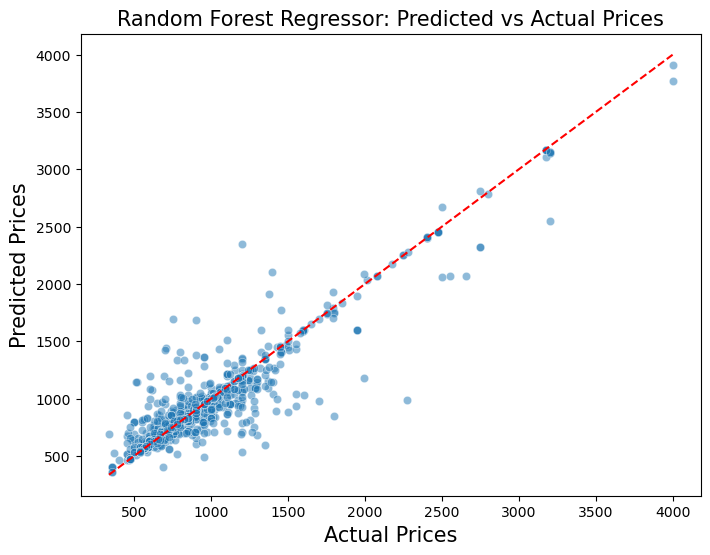

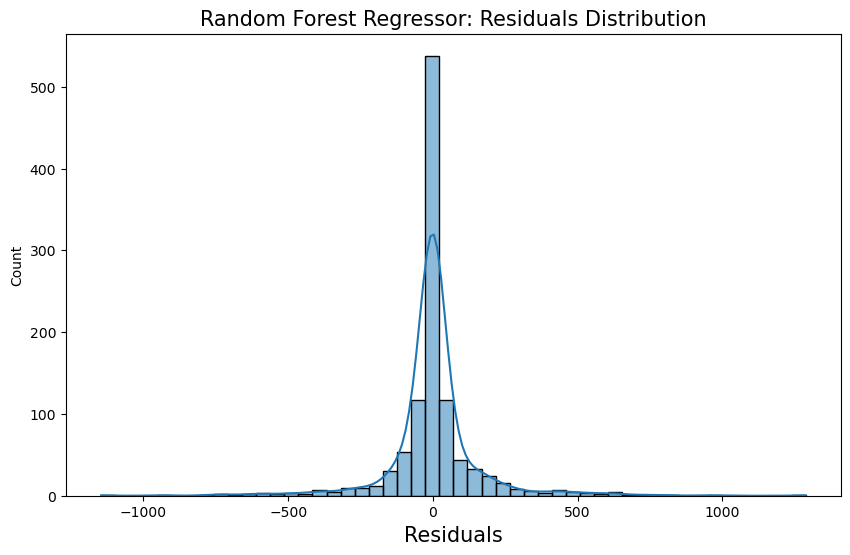

In [274]:
warnings.filterwarnings('ignore')

# ----------------------------------------
# 1. Load and Inspect the Dataset
# ----------------------------------------

df = filter_data.drop(columns=['url'])

print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values in Each Column:")
print(df.isnull().sum())

if 'price_rent_log' in df.columns:
    df = df.drop(columns=['price_rent_log'])

# ----------------------------------------
# 2. Data Preprocessing
# ----------------------------------------

# Define target variable
target = 'price_rent' 

# Drop rows where target is missing
df = df.dropna(subset=[target]).reset_index(drop=True)

# Identify numerical and categorical features
numerical_features = ['sqfeet', 'beds', 'baths', 'cats_allowed', 'dogs_allowed', 'smoking_allowed']
categorical_features = ['region', 'state']

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

# Handle missing values
# For numerical features, fill with median
for col in numerical_features:
    median = df[col].median()
    df[col].fillna(median, inplace=True)

# For categorical features, fill with mode
for col in categorical_features:
    mode = df[col].mode()[0]
    df[col].fillna(mode, inplace=True)

# Verify no missing values remain
print("\nMissing Values After Imputation:")
print(df.isnull().sum())

# Encode categorical variables using get_dummies
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# print("\nDataset after encoding:")
# print(df_encoded.head())

# Define feature matrix X and target vector y
X = df_encoded.drop([target], axis=1)
y = df_encoded[target]

# ----------------------------------------
# 3. Train-Test Split
# ----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=84)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# ----------------------------------------
# 4. Train the RandomForestRegressor Model
# ----------------------------------------

print("\nTraining Random Forest Regressor...")

# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=84)

# Train the model
rf_model.fit(X_train, y_train)

# ----------------------------------------
# 5. Evaluate the Model
# ----------------------------------------

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Regressor - MSE: {mse_rf:.2f}")
print(f"Random Forest Regressor - R²: {r2_rf:.2f}")

# Plot Predicted vs Actual Prices
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Prices', fontsize=15)
plt.ylabel('Predicted Prices', fontsize=15)
plt.title('Random Forest Regressor: Predicted vs Actual Prices', fontsize=15)
plt.show()

# Plot Residuals Distribution
residuals_rf = y_test - y_pred_rf
plt.figure(figsize=(10,6))
sns.histplot(residuals_rf, bins=50, kde=True)
plt.xlabel('Residuals', fontsize=15)
plt.title('Random Forest Regressor: Residuals Distribution', fontsize=15)
plt.show()


Analyzing Feature Importances for Random Forest Regressor...


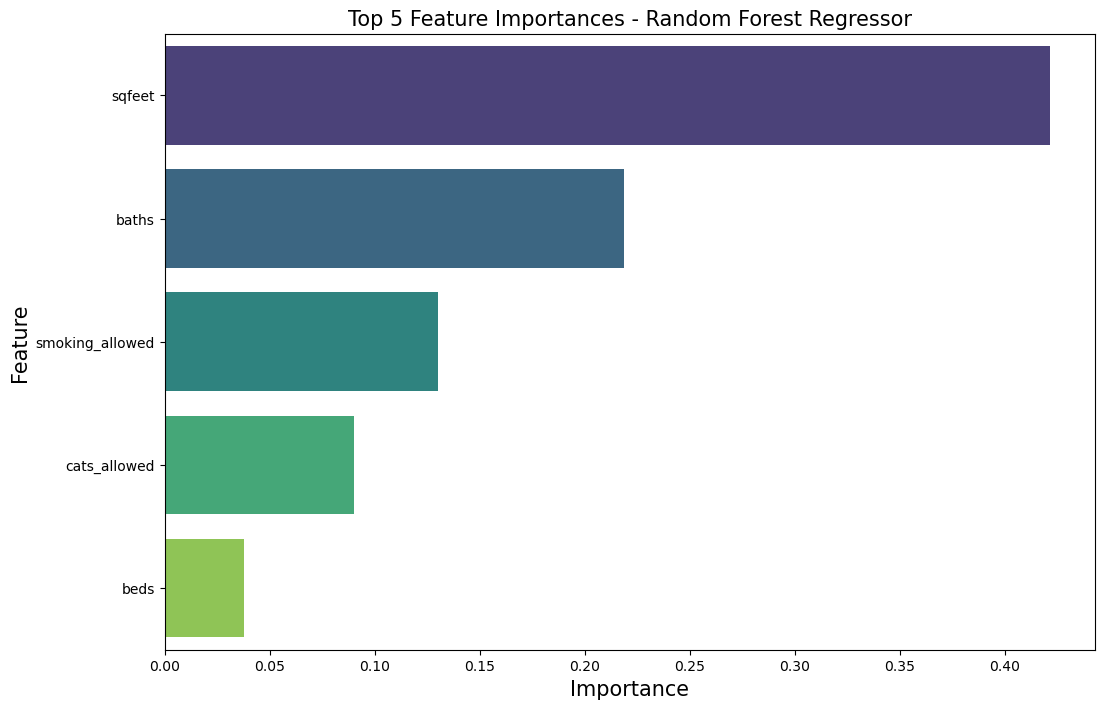

In [275]:
from IPython.display import display
# ----------------------------------------
# 6. Feature Importance Analysis
# ----------------------------------------

print("\nAnalyzing Feature Importances for Random Forest Regressor...")

# Get feature importances
importances_rf = rf_model.feature_importances_
feature_names = X.columns

# Create a Series for visualization
feature_importances_rf = pd.Series(importances_rf, index=feature_names).sort_values(ascending=False)

# Plot Top 5 Feature Importances
plt.figure(figsize=(12,8))
sns.barplot(x=feature_importances_rf.values[:5], y=feature_importances_rf.index[:5], palette='viridis')
plt.title('Top 5 Feature Importances - Random Forest Regressor', fontsize=15)
plt.xlabel('Importance', fontsize=15)
plt.ylabel('Feature', fontsize=15)
plt.show()

# ----------------------------------------
# 7. Recommendation Function Implementation
# ----------------------------------------

def recommend_properties(model, df, df_encoded, budget, beds=None, baths=None, sqfeet=None,
                         cats_allowed=None, dogs_allowed=None, smoking_allowed=None,
                         region=None, state=None, top_n=5):
    """
    Recommend top N properties based on user preferences and budget.
    
    Parameters:
    - model (RandomForestRegressor): Trained Random Forest model
    - df (DataFrame): Original DataFrame
    - df_encoded (DataFrame): Encoded DataFrame used in model training
    - budget (float): Maximum rent price
    - beds (int, optional): Minimum number of bedrooms
    - baths (int, optional): Minimum number of bathrooms
    - sqfeet (int, optional): Minimum square footage
    - cats_allowed (int, optional): 1 for allowed, 0 for not allowed
    - dogs_allowed (int, optional): 1 for allowed, 0 for not allowed
    - smoking_allowed (int, optional): 1 for allowed, 0 for not allowed
    - region (str, optional): Desired region
    - state (str, optional): Desired state
    - top_n (int, optional): Number of top recommendations to return
    
    Returns:
    - recommendations (DataFrame): Top N recommended properties with original columns
    """
    # Start with filtering by budget on original DataFrame
    filtered_df = df[df['price_rent'] <= budget].copy()
    
    # Apply additional filters if specified
    if beds is not None:
        filtered_df = filtered_df[filtered_df['beds'] >= beds]
    if baths is not None:
        filtered_df = filtered_df[filtered_df['baths'] >= baths]
    if sqfeet is not None:
        filtered_df = filtered_df[filtered_df['sqfeet'] >= sqfeet]
    if cats_allowed is not None:
        filtered_df = filtered_df[filtered_df['cats_allowed'] == cats_allowed]
    if dogs_allowed is not None:
        filtered_df = filtered_df[filtered_df['dogs_allowed'] == dogs_allowed]
    if smoking_allowed is not None:
        filtered_df = filtered_df[filtered_df['smoking_allowed'] == smoking_allowed]
    if region is not None:
        filtered_df = filtered_df[filtered_df['region'] == region]
    if state is not None:
        filtered_df = filtered_df[filtered_df['state'] == state]
    
    if filtered_df.empty:
        print("No properties match your criteria.")
        return pd.DataFrame()
    
    # Prepare the data for prediction
    # Encode the filtered data
    filtered_df_encoded = pd.get_dummies(filtered_df, columns=categorical_features, drop_first=True)
    
    # Align the encoded features with X.columns
    filtered_df_encoded = filtered_df_encoded.reindex(columns=X.columns, fill_value=0)
    
    # Predict the price
    predicted_prices = model.predict(filtered_df_encoded)
    
    # Add predicted prices to the original filtered dataframe
    filtered_df = filtered_df.copy()
    filtered_df['predicted_price'] = predicted_prices
    
    # Sort by predicted price
    recommendations = filtered_df.sort_values(by='predicted_price').head(top_n)
    
    # Drop 'predicted_price' column if you don't want to display it
    recommendations = recommendations.drop(columns=['predicted_price'])
    
    return recommendations

# ----------------------------------------
# 8. Prediction Function Implementation
# ----------------------------------------

def predict_housing(model, input_data):
    """
    Predict the rental price based on user inputs.
    
    Parameters:
    - model (RandomForestRegressor): Trained Random Forest model
    - input_data (dict): Dictionary containing property features
    
    Returns:
    - predicted_price (float): Predicted rental price
    """
    # Convert input_data to DataFrame
    input_df = pd.DataFrame([input_data])
    
    # Handle missing features by filling with median or mode as done in training
    for col in numerical_features:
        if col not in input_df.columns:
            input_df[col] = df[col].median()
    
    for col in categorical_features:
        if col not in input_df.columns:
            input_df[col] = df[col].mode()[0]
    
    # Encode categorical variables using get_dummies
    input_encoded = pd.get_dummies(input_df, columns=categorical_features, drop_first=True)
    
    # Align the input with training data columns
    input_encoded = input_encoded.reindex(columns=X.columns, fill_value=0)
    
    # Predict the price
    predicted_price = model.predict(input_encoded)[0]
    
    return predicted_price

In [264]:
# ----------------------------------------
# 9. Example Usage of the Recommendation Function
# ----------------------------------------

# Define user preferences
user_budget = 1500  # Maximum rent price
user_beds = 2        # Minimum number of bedrooms
user_baths = 2       # Minimum number of bathrooms
user_sqfeet = 300    # Minimum square footage
user_cats_allowed = 1  # 1 for True, 0 for False
user_dogs_allowed = 0  # 1 for True, 0 for False
user_smoking_allowed = 0  # 1 for True, 0 for False
user_region = None  # Desired region (exact match based on data)
user_state =  None  # Desired state (exact match based on data)

# Get recommendations
recommended_properties = recommend_properties(
    model=rf_model,
    df=filter_data,
    df_encoded=df_encoded,
    budget=user_budget,
    beds=user_beds,
    baths=user_baths,
    sqfeet=user_sqfeet,
    cats_allowed=user_cats_allowed,
    dogs_allowed=user_dogs_allowed,
    smoking_allowed=user_smoking_allowed,
    region=user_region,
    state=user_state,
    top_n=5
)

print("\nTop 5 Recommended Properties:")
display(recommended_properties)

# ----------------------------------------
# 10. Example Usage of the Prediction Function
# ----------------------------------------

# Example: Predict rental price based on user inputs
user_input = {
    'beds': 3,
    'baths': 2,
    'sqfeet': 1200,
    'cats_allowed': 1,   
    'dogs_allowed': 0,
    'smoking_allowed': 0,
    'region': 'champaign urbana',
    'state': 'IL'
}

predicted_price = predict_housing(
    model=rf_model,
    input_data=user_input
)

print(f"\nPredicted Rental Price: ${predicted_price:.2f}")


Top 5 Recommended Properties:


,price_rent,url,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,region,state
54328,550,https://springfieldil.craigslist.org/apa/d/spr...,980,2,2.0,1,0,0,springfield,il
54407,850,https://springfieldil.craigslist.org/apa/d/spr...,1200,3,2.0,1,0,0,springfield,il
53620,805,https://quadcities.craigslist.org/apa/d/davenp...,870,2,2.0,1,0,0,"quad cities, IA/IL",il
53223,825,https://quadcities.craigslist.org/apa/d/davenp...,960,3,2.0,1,0,0,"quad cities, IA/IL",il
53524,825,https://quadcities.craigslist.org/apa/d/davenp...,960,3,2.0,1,0,0,"quad cities, IA/IL",il



Predicted Rental Price: $883.48


In [271]:
# ----------------------------------------
# 11. Interactive Usage
# ----------------------------------------

print("Welcome to the IL House rental Recommendation System!")
budget = float(input("Enter your budget: $"))
min_bedrooms = int(input("Enter the minimum number of bedrooms: "))
min_bathrooms = int(input("Enter the minimum number of bathrooms: "))
min_sqfeet = int(input("Enter the minimum number of area in sqfeet: "))
cats = int(input("Do you want to have cats allowed in your house? (1 for yes, 0 for no):"))
dogs = int(input("Do you want to have dogs allowed in your house? (1 for yes, 0 for no):"))
smoking = int(input("Do you want to have smoking allowed in your house? (1 for yes, 0 for no):"))

recommended_properties = recommend_properties(
    model=rf_model,
    df=filter_data,
    df_encoded=df_encoded,
    budget=budget,
    beds=min_bedrooms,
    baths=min_bathrooms,
    sqfeet=min_sqfeet,
    cats_allowed=cats,
    dogs_allowed=dogs,
    smoking_allowed=smoking,
    region=None,
    state=None,
    top_n=3
)

print("Recommended Properties:")
display(recommended_properties)

user_input = {
    'beds': min_bedrooms,
    'baths': min_bathrooms,
    'sqfeet': min_sqfeet,
    'cats_allowed': cats,   
    'dogs_allowed': dogs,
    'smoking_allowed': smoking,
    'region':None,
    'state': None
}

predicted_price = predict_housing(
    model=rf_model,
    input_data=user_input
)

print(f"\nPredicted Rental Price: ${predicted_price:.2f}")

Welcome to the IL House rental Recommendation System!
Recommended Properties:


,price_rent,url,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,region,state
49895,355,https://bn.craigslist.org/apa/d/normal-isu-iwu...,900,2,1.0,0,0,0,bloomington-normal,il
50116,355,https://bn.craigslist.org/apa/d/normal-isu-iwu...,900,2,1.0,0,0,0,bloomington-normal,il
50123,355,https://bn.craigslist.org/apa/d/normal-isu-iwu...,900,2,1.0,0,0,0,bloomington-normal,il



Predicted Rental Price: $560.81
